In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
import pandas as pd

df= pd.read_csv("upi_fraud_dataset.csv")
df.head()

,Id,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
0,0,0,1,1,2022,12,9957000001,54,66.21,22,49879,0
1,1,1,1,1,2022,3,9957000002,15,55.81,14,62668,0
2,2,3,1,1,2022,8,9957000003,60,8.68,4,96037,0
3,3,6,1,1,2022,4,9957000004,44,89.52,40,29911,0
4,4,6,1,1,2022,0,9957000005,72,1.90,38,16421,0


In [18]:
x=df.drop(["upi_number","fraud_risk"],axis=1)
y=df["fraud_risk"]

In [19]:
import pandas as pd


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9625468164794008


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[205  15]
 [  5 309]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       220
           1       0.95      0.98      0.97       314

    accuracy                           0.96       534
   macro avg       0.96      0.96      0.96       534
weighted avg       0.96      0.96      0.96       534



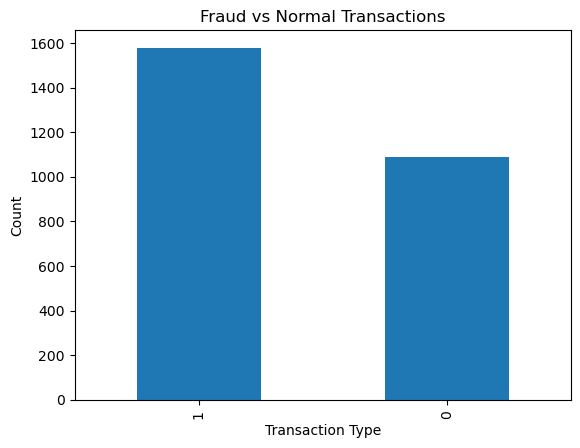

In [26]:
import matplotlib.pyplot as plt

df['fraud_risk'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### reading the dataset :

In [27]:
import pickle

pickle.dump(model,open("fraud_model.pkl","wb"))

This project developed a machine learning model to detect fraudulent UPI transactions. The dataset was preprocessed and split into training and testing sets. A Random Forest classifier was used to train the model. The model achieved an accuracy of approximately 95.88%, showing that machine learning can effectively detect fraudulent transactions and help improve the security of digital payment systems.

Implement deep learning models for better fraud detection
                               
Deploy the model as a web application
                               
Use real-time transaction monitoring
                               
Improve accuracy using feature engineering

### first five rows:

In [ ]:
df.head()

### info about the dataset:

In [ ]:
df.info()

In [ ]:
df.tail()

### size of the df:

In [ ]:
df.shape

### checking frequency of values in each categorical columns :

In [ ]:
df['type'].value_counts()

In [ ]:
df['isFlaggedFraud'].value_counts()

In [ ]:
df['isFraud'].value_counts()

In [ ]:
df[(df['type']=='TRANSFER') | (df['type']=='PAYEMENT')]['isFraud'].value_counts()

### removing isFlaggedFraud column:

In [ ]:
df=df.drop('isFlaggedFraud',axis=1)

In [ ]:
df['isFraud'].value_counts()

### dropping all rows from df where type column contains either 'CASH_OUT' or 'CASH_IN' or 'DEBIT':

In [ ]:
df = df[df['type'].isin(['TRANSFER', 'PAYMENT'])]

In [ ]:
df.shape

# duplicated rows:

In [ ]:
df[df.duplicated()]

### checking anny null values in the df:

In [ ]:
df.isnull().sum()

In [ ]:
df

# Feture Engineering :Creating New Features

## 1.1 Transaction Time Features :
- hour: Extracts the hour of the transaction.
- is_night: Flags transactions occurring between midnight and 6 AM (higher fraud probability).

In [ ]:
df['hour'] = df['step'] % 24  # Extract hour from step (since 1 step = 1 hour)
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)  # Flag night transactions

In [ ]:
df.head()

### 1.2 Transaction Amount Features
- Compare transaction amounts with sender's balance.
- amount_ratio: Measures how significant the transaction amount is compared to the sender's balance.
- High values (~1) might indicate risky transactions.

In [ ]:
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # Avoid division by zero

In [ ]:
df.head()

### 1.3 Balance Difference Features
- Check unexpected balance changes.
- sender_balance_change: Difference between sender's old and new balance.
- receiver_balance_change: Difference between recipient's old and new balance.
#### Fraudulent transactions may not update balances correctly.

In [ ]:
df['sender_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

In [ ]:
df[df['isFraud']==1]

### 1.4 Unexpected Zero Balances
- In fraudulent transactions, balances might remain unchanged.
- orig_balance_zero: Indicates whether the sender had a zero balance before the transaction.
- dest_balance_zero: Indicates whether the receiver had a zero balance before the transaction.
#### Fraudsters may use new accounts with zero balance to receive money.


In [ ]:
df['orig_balance_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['dest_balance_zero'] = (df['oldbalanceDest'] == 0).astype(int)

In [ ]:
df.sample(4)

In [ ]:
df[df['isFraud']==1]

### 2. Encoding Categorical Features
- Convert categorical variables into numerical representations.
- Encodes the type column (e.g., CASH_OUT, TRANSFER) using one-hot encoding.

In [ ]:
dummies=pd.get_dummies(df['type']).astype(int)
dummies.tail()

In [ ]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df.head()

In [ ]:
df['type_TRANSFER'] = df['type_TRANSFER'].astype(int)
df.head()

## 3. Dropping Irrelevant Columns :

In [ ]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [ ]:
df.shape

In [ ]:
df.sample(10)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr ,annot=True)

In [ ]:
df.describe()

# independent and dependent features:

In [ ]:
X=df.drop('isFraud',axis=1)
y=df['isFraud']

In [ ]:
X

In [ ]:
y

# tran-test-split :

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

# Model training :

## Logistic Regression :

### scaling the values :

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train_scaled

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=10000)

In [ ]:
lr.fit(X_train_scaled,y_train)

In [ ]:
y_pred1=lr.predict(X_test_scaled)
y_pred1

# Check the accuracy of the logistic regression model :¶

In [ ]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

acc_score=accuracy_score(y_test,y_pred1)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred1))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred1))

## Decision Tree Classifier :

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier(max_depth=5,class_weight={0: 1, 1: 10})

In [ ]:
dt.fit(X_train,y_train)

## Visualize the Decision Tree

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt,filled=True)

In [ ]:
dt.get_depth()

In [ ]:
y_pred=dt.predict(X_test)

In [ ]:
y_pred

# Check the accuracy of the model :

In [ ]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

In [ ]:
acc_score=accuracy_score(y_test,y_pred)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))

#  Trying RandomForest since DecisionTreeClassifier with accuracay 99.99% leads to overfitting since max_depth =None

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,class_weight={0: 1, 1: 10}, random_state=42)

In [ ]:
rf_model.fit(X_train, y_train)

In [ ]:
y_pred = rf_model.predict(X_test)
y_pred

### accuracy of this model along with classification report :

In [ ]:
acc_score=accuracy_score(y_test,y_pred)*100
print(f"accuracy score :{acc_score} %")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))